# GeoMM-Bench: Comprehensive Multimodal Evaluation
## Text-Only, Vision-Only, and Multimodal Lithofacies Classification

---

### Objective

This notebook provides an end-to-end evaluation of three approaches for lithofacies classification:

1. **Text-Only**: Classification using geological descriptions
2. **Vision-Only**: Classification using well log images with visual grounding
3. **Multimodal**: Combined text and vision approaches

### Dataset

- Well: Vilkyciai-22 (Lithuania)
- Depth range: 1975-2215m TVD
- Scale: 1:500
- Classes: Sandstone, Shale, Limestone, Dolomite
- Intervals: 11 labeled depth intervals

### Models Used

| Approach | Model | Capability |
|----------|-------|------------|
| Text-Only | CLIP (text encoder) | Text embedding similarity |
| Vision-Only | Grounding DINO | Visual grounding with bounding boxes |
| Vision-Only | CLIP (vision encoder) | Image embedding similarity |
| Multimodal | BLIP-2 | Vision-language QA |
| Multimodal | Combined CLIP | Fused text + vision embeddings |

In [ ]:
# ==================================================
# CELL 1: Install Dependencies
# ==================================================

!pip install -q torch torchvision
!pip install -q transformers>=4.35.0
!pip install -q open-clip-torch
!pip install -q Pillow matplotlib pandas numpy
!pip install -q scikit-learn
!pip install -q pdf2image  # For PDF conversion

print("All dependencies installed.")

In [1]:
# ==================================================
# CELL 2: Device Configuration
# ==================================================

import torch
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')

def get_device():
    """Select the best available device."""
    if torch.backends.mps.is_available():
        return "mps", torch.float32
    elif torch.cuda.is_available():
        return "cuda", torch.float16
    else:
        return "cpu", torch.float32

DEVICE, DTYPE = get_device()
print(f"Device: {DEVICE}")
print(f"Dtype: {DTYPE}")

Device: mps
Dtype: torch.float32


In [2]:
# ==================================================
# CELL 3: Configuration
# ==================================================

CONFIG = {
    # Input PDF files (update paths as needed)
    "logs_pdf": "vilkyciai22_logs500.pdf",
    "interp_pdf": "vilkyciai22_interp500.pdf",
    "fws_pdf": "vilkyciai22_fws_im_dt.pdf",
    
    # Output directories
    "image_dir": "converted_images",
    "output_dir": "geomm_results",
    
    # Well metadata
    "well_name": "Vilkyciai-22",
    "country": "Lithuania",
    "scale": "1:500",
    
    # Evaluation settings
    "box_threshold": 0.25,
    "text_threshold": 0.25,
}

# Create directories
Path(CONFIG["image_dir"]).mkdir(exist_ok=True)
Path(CONFIG["output_dir"]).mkdir(exist_ok=True)

print("Configuration set.")
print(f"Well: {CONFIG['well_name']} ({CONFIG['country']})")

Configuration set.
Well: Vilkyciai-22 (Lithuania)


In [3]:
# ==================================================
# CELL 4: Ground Truth Data
# ==================================================

import pandas as pd

# Ground truth intervals with geological descriptions
GROUND_TRUTH = [
    {
        "id": 1,
        "start_depth": 1975,
        "end_depth": 1995,
        "lithology": "shale",
        "page": 2,
        "description": "High gamma ray readings above 100 GAPI indicating clay-rich formation. "
                       "Mineral model shows dominant clay volume with magenta coloring. "
                       "Low resistivity and high neutron porosity typical of shale.",
        "visual_features": "magenta fill, high GR deflection right, low resistivity"
    },
    {
        "id": 2,
        "start_depth": 1995,
        "end_depth": 2015,
        "lithology": "shale",
        "page": 2,
        "description": "Continued high gamma ray response. Clay-dominated interval with "
                       "characteristic shale properties. Density-neutron crossover present.",
        "visual_features": "magenta fill, hatched pattern, high GR"
    },
    {
        "id": 3,
        "start_depth": 2015,
        "end_depth": 2035,
        "lithology": "limestone",
        "page": 2,
        "description": "Sharp decrease in gamma ray to below 30 GAPI. Mineral model shows "
                       "calcite-dominated composition with green coloring. High density "
                       "around 2.71 g/cc consistent with limestone matrix.",
        "visual_features": "green fill, low GR deflection left, high density"
    },
    {
        "id": 4,
        "start_depth": 2035,
        "end_depth": 2060,
        "lithology": "limestone",
        "page": 3,
        "description": "Clean carbonate interval with low gamma ray. Calcite cement visible "
                       "in mineral model. Moderate porosity indicated by density-neutron separation.",
        "visual_features": "green fill dominant, clean GR baseline"
    },
    {
        "id": 5,
        "start_depth": 2060,
        "end_depth": 2085,
        "lithology": "limestone",
        "page": 3,
        "description": "Limestone with minor clay content. Gamma ray slightly elevated but "
                       "still in carbonate range. Good porosity development.",
        "visual_features": "green fill with minor magenta, moderate GR"
    },
    {
        "id": 6,
        "start_depth": 2085,
        "end_depth": 2110,
        "lithology": "limestone",
        "page": 3,
        "description": "Pure limestone interval. Very low gamma ray and high density. "
                       "Mineral model shows nearly pure calcite composition.",
        "visual_features": "solid green fill, very low GR, high density track"
    },
    {
        "id": 7,
        "start_depth": 2110,
        "end_depth": 2125,
        "lithology": "limestone",
        "page": 3,
        "description": "Transition zone at base of carbonate sequence. Limestone with "
                       "increasing siliciclastic content toward base.",
        "visual_features": "green fill transitioning, GR slightly increasing"
    },
    {
        "id": 8,
        "start_depth": 2125,
        "end_depth": 2145,
        "lithology": "sandstone",
        "page": 3,
        "description": "Quartz-rich sandstone with low gamma ray. Mineral model shows "
                       "yellow coloring indicating sand/quartz dominance. Good porosity.",
        "visual_features": "yellow fill, low GR, cyan water saturation"
    },
    {
        "id": 9,
        "start_depth": 2145,
        "end_depth": 2170,
        "lithology": "sandstone",
        "page": 4,
        "description": "Clean sandstone reservoir interval. Very low gamma ray below 20 GAPI. "
                       "High porosity visible in density-neutron overlay. Potential hydrocarbon zone.",
        "visual_features": "yellow fill dominant, very low GR, high porosity indication"
    },
    {
        "id": 10,
        "start_depth": 2170,
        "end_depth": 2195,
        "lithology": "sandstone",
        "page": 4,
        "description": "Continued sand development with excellent reservoir properties. "
                       "Uniform low gamma ray signature throughout interval.",
        "visual_features": "yellow fill, consistent low GR, good porosity"
    },
    {
        "id": 11,
        "start_depth": 2195,
        "end_depth": 2215,
        "lithology": "shale",
        "page": 4,
        "description": "Return to shale facies. Gamma ray increases sharply above 80 GAPI. "
                       "Clay volume dominates mineral model. Base of reservoir section.",
        "visual_features": "magenta fill returns, GR spike right, low resistivity"
    },
]

# Convert to DataFrame
df_ground_truth = pd.DataFrame(GROUND_TRUTH)

print(f"Ground truth: {len(GROUND_TRUTH)} intervals")
print(f"\nLithology distribution:")
print(df_ground_truth['lithology'].value_counts())

# Define lithology classes
LITHOLOGY_CLASSES = ["sandstone", "shale", "limestone", "dolomite"]

Ground truth: 11 intervals

Lithology distribution:
lithology
limestone    5
shale        3
sandstone    3
Name: count, dtype: int64


In [4]:
# ==================================================
# CELL 5: PDF to Image Conversion
# ==================================================

from pdf2image import convert_from_path
from PIL import Image
import numpy as np

def convert_pdf_to_images(pdf_path, output_prefix, dpi=150):
    """
    Convert PDF pages to PNG images.
    
    Args:
        pdf_path: Path to PDF file
        output_prefix: Prefix for output files
        dpi: Resolution for conversion
    
    Returns:
        List of output image paths
    """
    if not os.path.exists(pdf_path):
        print(f"WARNING: PDF not found: {pdf_path}")
        return []
    
    print(f"Converting: {pdf_path}")
    
    images = convert_from_path(pdf_path, dpi=dpi)
    output_paths = []
    
    for i, img in enumerate(images):
        output_path = f"{CONFIG['image_dir']}/{output_prefix}_page_{i+1}.png"
        img.save(output_path, "PNG")
        output_paths.append(output_path)
        print(f"  Saved: {output_path} ({img.size})")
    
    return output_paths

# Convert all PDFs
print("="*60)
print("Converting PDFs to images...")
print("="*60)

logs_images = convert_pdf_to_images(CONFIG["logs_pdf"], "logs")
interp_images = convert_pdf_to_images(CONFIG["interp_pdf"], "interp")
fws_images = convert_pdf_to_images(CONFIG["fws_pdf"], "fws")

print(f"\nTotal images: {len(logs_images) + len(interp_images) + len(fws_images)}")

Converting PDFs to images...
Converting: vilkyciai22_logs500.pdf
  Saved: converted_images/logs_page_1.png ((1275, 1650))
  Saved: converted_images/logs_page_2.png ((1275, 1650))
  Saved: converted_images/logs_page_3.png ((1275, 1650))
  Saved: converted_images/logs_page_4.png ((1275, 1650))
Converting: vilkyciai22_interp500.pdf
  Saved: converted_images/interp_page_1.png ((1275, 1650))
  Saved: converted_images/interp_page_2.png ((1275, 1650))
  Saved: converted_images/interp_page_3.png ((1275, 1650))
  Saved: converted_images/interp_page_4.png ((1275, 1650))

Total images: 8


In [5]:
# ==================================================
# CELL 6: Build Image Path Mapping
# ==================================================

# Map page numbers to image paths
def build_image_mapping():
    """Build mapping from page numbers to image paths."""
    mapping = {"logs": {}, "interp": {}, "fws": {}}
    
    image_dir = CONFIG["image_dir"]
    
    for f in os.listdir(image_dir):
        if f.endswith(".png"):
            path = os.path.join(image_dir, f)
            
            if f.startswith("logs_page_"):
                page = int(f.split("_")[-1].replace(".png", ""))
                mapping["logs"][page] = path
            elif f.startswith("interp_page_"):
                page = int(f.split("_")[-1].replace(".png", ""))
                mapping["interp"][page] = path
            elif f.startswith("fws_page_"):
                page = int(f.split("_")[-1].replace(".png", ""))
                mapping["fws"][page] = path
    
    return mapping

IMAGE_PATHS = build_image_mapping()

print("Image mapping:")
for img_type, pages in IMAGE_PATHS.items():
    print(f"  {img_type}: {list(pages.keys())}")

Image mapping:
  logs: [4, 2, 3, 1]
  interp: [1, 2, 3, 4]
  fws: []


In [6]:
# ==================================================
# CELL 7: Load CLIP Model (for Text-Only and Vision)
# ==================================================

import open_clip

print("Loading CLIP model...")

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    'ViT-B-32',
    pretrained='laion2b_s34b_b79k'
)
clip_model = clip_model.to(DEVICE)
clip_model.eval()

clip_tokenizer = open_clip.get_tokenizer('ViT-B-32')

print(f"CLIP loaded on {DEVICE}")

Loading CLIP model...


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP loaded on mps


In [7]:
# ==================================================
# CELL 8: Load Grounding DINO Model (for Visual Grounding)
# ==================================================

from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

print("Loading Grounding DINO model...")

GDINO_MODEL_ID = "IDEA-Research/grounding-dino-tiny"

gdino_processor = AutoProcessor.from_pretrained(GDINO_MODEL_ID)
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(GDINO_MODEL_ID)
gdino_model = gdino_model.to(DEVICE)
gdino_model.eval()

print(f"Grounding DINO loaded on {DEVICE}")

Loading Grounding DINO model...


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Grounding DINO loaded on mps


In [8]:
# ==================================================
# CELL 9: Load BLIP-2 Model (for Multimodal VQA)
# ==================================================

from transformers import Blip2Processor, Blip2ForConditionalGeneration

print("Loading BLIP-2 model...")

BLIP2_MODEL_ID = "Salesforce/blip2-opt-2.7b"

blip2_processor = Blip2Processor.from_pretrained(BLIP2_MODEL_ID)
blip2_model = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_MODEL_ID,
    torch_dtype=DTYPE
)
blip2_model = blip2_model.to(DEVICE)
blip2_model.eval()

print(f"BLIP-2 loaded on {DEVICE}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading BLIP-2 model...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

BLIP-2 loaded on mps


In [9]:
# ==================================================
# CELL 10: Text-Only Classification Functions
# ==================================================

def get_text_embeddings(texts):
    """Get CLIP text embeddings."""
    tokens = clip_tokenizer(texts).to(DEVICE)
    with torch.no_grad():
        embeddings = clip_model.encode_text(tokens)
        embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)
    return embeddings

def classify_text_only(description, class_prompts):
    """
    Classify using text description only.
    
    Args:
        description: Geological description of the interval
        class_prompts: Dict mapping class names to text prompts
    
    Returns:
        Dict with predicted class and probabilities
    """
    # Get embeddings
    desc_embedding = get_text_embeddings([description])
    class_embeddings = get_text_embeddings(list(class_prompts.values()))
    
    # Compute similarities
    similarities = (desc_embedding @ class_embeddings.T).squeeze(0)
    probabilities = torch.softmax(similarities * 100, dim=0).cpu().numpy()
    
    # Get prediction
    class_names = list(class_prompts.keys())
    pred_idx = probabilities.argmax()
    
    return {
        "predicted": class_names[pred_idx],
        "confidence": float(probabilities[pred_idx]),
        "probabilities": {c: float(p) for c, p in zip(class_names, probabilities)}
    }

# Define text prompts for each lithology class
TEXT_CLASS_PROMPTS = {
    "sandstone": "A geological formation dominated by quartz sand grains with low gamma ray, "
                 "yellow coloring in mineral models, and good porosity.",
    "shale": "A clay-rich formation with high gamma ray readings above 80 GAPI, "
             "magenta coloring in mineral models, and low permeability.",
    "limestone": "A carbonate formation dominated by calcite with low gamma ray, "
                 "green coloring in mineral models, and high density around 2.71 g/cc.",
    "dolomite": "A carbonate formation dominated by dolomite mineral with very low gamma ray, "
                "cyan coloring in mineral models, and very high density above 2.85 g/cc.",
}

print("Text-only classification ready.")

Text-only classification ready.


In [10]:
# ==================================================
# CELL 11: Vision-Only Classification Functions (CLIP)
# ==================================================

def get_image_embedding(image):
    """Get CLIP image embedding."""
    image_tensor = clip_preprocess(image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        embedding = clip_model.encode_image(image_tensor)
        embedding = embedding / embedding.norm(dim=-1, keepdim=True)
    return embedding

def classify_vision_clip(image, class_prompts):
    """
    Classify using image only with CLIP.
    
    Args:
        image: PIL Image
        class_prompts: Dict mapping class names to visual prompts
    
    Returns:
        Dict with predicted class and probabilities
    """
    # Get embeddings
    image_embedding = get_image_embedding(image)
    class_embeddings = get_text_embeddings(list(class_prompts.values()))
    
    # Compute similarities
    similarities = (image_embedding @ class_embeddings.T).squeeze(0)
    probabilities = torch.softmax(similarities * 100, dim=0).cpu().numpy()
    
    # Get prediction
    class_names = list(class_prompts.keys())
    pred_idx = probabilities.argmax()
    
    return {
        "predicted": class_names[pred_idx],
        "confidence": float(probabilities[pred_idx]),
        "probabilities": {c: float(p) for c, p in zip(class_names, probabilities)}
    }

# Visual prompts for CLIP
VISION_CLASS_PROMPTS = {
    "sandstone": "A well log image showing yellow filled regions with low gamma ray curve deflection.",
    "shale": "A well log image showing magenta or hatched filled regions with high gamma ray curve deflection.",
    "limestone": "A well log image showing green filled regions with low gamma ray curve deflection.",
    "dolomite": "A well log image showing cyan filled regions with very low gamma ray curve deflection.",
}

print("Vision-only CLIP classification ready.")

Vision-only CLIP classification ready.


In [16]:
# ==================================================
# CELL 12: Vision-Only with Grounding DINO
# ==================================================

def detect_with_grounding_dino(image, query, box_threshold=0.25, text_threshold=0.25):
    """
    Detect objects using Grounding DINO.
    
    Args:
        image: PIL Image
        query: Text query (dot-separated for multiple objects)
        box_threshold: Confidence threshold for boxes
        text_threshold: Confidence threshold for text matching
    
    Returns:
        Dict with boxes, scores, labels
    """
    inputs = gdino_processor(images=image, text=query, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = gdino_model(**inputs)
    
    results = gdino_processor.post_process_grounded_object_detection(
        outputs,
        inputs["input_ids"],
        threshold=box_threshold,  # API changed: box_threshold -> threshold
        text_threshold=text_threshold,
        target_sizes=[image.size[::-1]]
    )[0]
    
    return {
        'boxes': results['boxes'].cpu().numpy(),
        'scores': results['scores'].cpu().numpy(),
        'labels': results['labels']
    }

def classify_vision_grounding(image, lithology_queries):
    """
    Classify using visual grounding - detect lithology-specific features.
    
    Args:
        image: PIL Image
        lithology_queries: Dict mapping lithology to visual query
    
    Returns:
        Dict with predicted class based on detection scores
    """
    detection_scores = {}
    all_detections = {}
    
    for lith, query in lithology_queries.items():
        results = detect_with_grounding_dino(image, query, box_threshold=0.15, text_threshold=0.15)
        
        # Score based on number of detections and confidence
        if len(results['scores']) > 0:
            score = float(np.mean(results['scores']) * len(results['scores']))
        else:
            score = 0.0
        
        detection_scores[lith] = score
        all_detections[lith] = results
    
    # Normalize scores to probabilities
    total = sum(detection_scores.values()) + 1e-8
    probabilities = {k: v/total for k, v in detection_scores.items()}
    
    # Get prediction
    predicted = max(probabilities, key=probabilities.get)
    
    return {
        "predicted": predicted,
        "confidence": probabilities[predicted],
        "probabilities": probabilities,
        "detections": all_detections
    }

# Grounding queries for each lithology (based on visual features)
GROUNDING_QUERIES = {
    "sandstone": "yellow region. yellow fill. sand colored area.",
    "shale": "magenta region. pink fill. hatched area.",
    "limestone": "green region. green fill. lime colored area.",
    "dolomite": "cyan region. blue fill. teal colored area.",
}

print("Vision grounding classification ready.")

Vision grounding classification ready.


In [12]:
# ==================================================
# CELL 13: Multimodal Classification with BLIP-2
# ==================================================

def classify_multimodal_blip2(image, description):
    """
    Classify using BLIP-2 multimodal model.
    
    Args:
        image: PIL Image
        description: Text description of the interval
    
    Returns:
        Dict with predicted class and response
    """
    # Construct prompt
    prompt = f"""This is a well log image from a petroleum well. 
Based on the image and this description: "{description}"
What is the lithology? Answer with one word: sandstone, shale, limestone, or dolomite."""
    
    # Process
    inputs = blip2_processor(images=image, text=prompt, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    
    # Generate
    with torch.no_grad():
        outputs = blip2_model.generate(**inputs, max_new_tokens=50)
    
    response = blip2_processor.decode(outputs[0], skip_special_tokens=True).strip().lower()
    
    # Extract lithology from response
    predicted = "unknown"
    for lith in LITHOLOGY_CLASSES:
        if lith in response:
            predicted = lith
            break
    
    return {
        "predicted": predicted,
        "response": response,
        "confidence": 1.0 if predicted != "unknown" else 0.0
    }

print("Multimodal BLIP-2 classification ready.")

Multimodal BLIP-2 classification ready.


In [13]:
# ==================================================
# CELL 14: Combined Multimodal (CLIP fusion)
# ==================================================

def classify_multimodal_clip_fusion(image, description, text_weight=0.6, vision_weight=0.4):
    """
    Classify using weighted fusion of CLIP text and vision.
    
    Args:
        image: PIL Image
        description: Text description
        text_weight: Weight for text-based prediction
        vision_weight: Weight for vision-based prediction
    
    Returns:
        Dict with predicted class and probabilities
    """
    # Get text prediction
    text_result = classify_text_only(description, TEXT_CLASS_PROMPTS)
    
    # Get vision prediction
    vision_result = classify_vision_clip(image, VISION_CLASS_PROMPTS)
    
    # Fuse probabilities
    fused_probs = {}
    for lith in LITHOLOGY_CLASSES:
        text_prob = text_result["probabilities"].get(lith, 0)
        vision_prob = vision_result["probabilities"].get(lith, 0)
        fused_probs[lith] = text_weight * text_prob + vision_weight * vision_prob
    
    # Normalize
    total = sum(fused_probs.values())
    fused_probs = {k: v/total for k, v in fused_probs.items()}
    
    # Get prediction
    predicted = max(fused_probs, key=fused_probs.get)
    
    return {
        "predicted": predicted,
        "confidence": fused_probs[predicted],
        "probabilities": fused_probs,
        "text_prediction": text_result["predicted"],
        "vision_prediction": vision_result["predicted"]
    }

print("Multimodal CLIP fusion ready.")

Multimodal CLIP fusion ready.


In [14]:
# ==================================================
# CELL 15: Crop Image to Depth Interval
# ==================================================

def crop_to_depth_interval(image, page, start_depth, end_depth):
    """
    Crop image to approximate depth interval.
    
    Note: This is approximate - adjust based on actual page layout.
    Assumes 1:500 scale with ~125m per page.
    
    Args:
        image: PIL Image of full page
        page: Page number
        start_depth: Start depth in meters
        end_depth: End depth in meters
    
    Returns:
        Cropped PIL Image
    """
    w, h = image.size
    
    # Approximate depth range per page (1:500 scale)
    # Page 2: ~1950-2050m, Page 3: ~2050-2175m, Page 4: ~2175-2300m
    page_depths = {
        2: (1950, 2050),
        3: (2025, 2150),
        4: (2125, 2250),
    }
    
    if page not in page_depths:
        return image
    
    page_start, page_end = page_depths[page]
    page_range = page_end - page_start
    
    # Header/footer margins (approximate)
    header_frac = 0.08
    footer_frac = 0.05
    usable_height = h * (1 - header_frac - footer_frac)
    
    # Calculate crop coordinates
    rel_start = (start_depth - page_start) / page_range
    rel_end = (end_depth - page_start) / page_range
    
    y1 = int(h * header_frac + usable_height * max(0, rel_start))
    y2 = int(h * header_frac + usable_height * min(1, rel_end))
    
    # Add some margin
    margin = int(h * 0.02)
    y1 = max(0, y1 - margin)
    y2 = min(h, y2 + margin)
    
    return image.crop((0, y1, w, y2))

print("Depth cropping function ready.")

Depth cropping function ready.


In [17]:
# ==================================================
# CELL 16: Run Full Evaluation
# ==================================================

import time

def run_full_evaluation():
    """
    Run evaluation across all approaches and intervals.
    
    Returns:
        DataFrame with all results
    """
    results = []
    
    print("="*70)
    print("RUNNING FULL EVALUATION")
    print("="*70)
    
    for i, gt in enumerate(GROUND_TRUTH):
        interval_id = gt["id"]
        start = gt["start_depth"]
        end = gt["end_depth"]
        true_label = gt["lithology"]
        description = gt["description"]
        page = gt["page"]
        
        print(f"\n[{i+1}/{len(GROUND_TRUTH)}] Interval {start}-{end}m (True: {true_label})")
        
        # Load image
        image_path = IMAGE_PATHS["logs"].get(page)
        if not image_path or not os.path.exists(image_path):
            print(f"  WARNING: Image not found for page {page}")
            continue
        
        full_image = Image.open(image_path).convert("RGB")
        cropped_image = crop_to_depth_interval(full_image, page, start, end)
        
        # Initialize result dict
        result = {
            "interval_id": interval_id,
            "start_depth": start,
            "end_depth": end,
            "true_label": true_label,
            "page": page,
        }
        
        # 1. Text-Only Classification
        print("  Running: Text-Only (CLIP)")
        text_result = classify_text_only(description, TEXT_CLASS_PROMPTS)
        result["text_only_pred"] = text_result["predicted"]
        result["text_only_conf"] = text_result["confidence"]
        result["text_only_correct"] = text_result["predicted"] == true_label
        print(f"    Predicted: {text_result['predicted']} ({text_result['confidence']:.3f})")
        
        # 2. Vision-Only Classification (CLIP)
        print("  Running: Vision-Only (CLIP)")
        vision_clip_result = classify_vision_clip(cropped_image, VISION_CLASS_PROMPTS)
        result["vision_clip_pred"] = vision_clip_result["predicted"]
        result["vision_clip_conf"] = vision_clip_result["confidence"]
        result["vision_clip_correct"] = vision_clip_result["predicted"] == true_label
        print(f"    Predicted: {vision_clip_result['predicted']} ({vision_clip_result['confidence']:.3f})")
        
        # 3. Vision-Only with Grounding (Grounding DINO)
        print("  Running: Vision-Only (Grounding DINO)")
        vision_ground_result = classify_vision_grounding(cropped_image, GROUNDING_QUERIES)
        result["vision_grounding_pred"] = vision_ground_result["predicted"]
        result["vision_grounding_conf"] = vision_ground_result["confidence"]
        result["vision_grounding_correct"] = vision_ground_result["predicted"] == true_label
        print(f"    Predicted: {vision_ground_result['predicted']} ({vision_ground_result['confidence']:.3f})")
        
        # 4. Multimodal BLIP-2
        print("  Running: Multimodal (BLIP-2)")
        blip2_result = classify_multimodal_blip2(cropped_image, description)
        result["multimodal_blip2_pred"] = blip2_result["predicted"]
        result["multimodal_blip2_correct"] = blip2_result["predicted"] == true_label
        print(f"    Predicted: {blip2_result['predicted']} (response: {blip2_result['response'][:50]}...)")
        
        # 5. Multimodal CLIP Fusion
        print("  Running: Multimodal (CLIP Fusion)")
        fusion_result = classify_multimodal_clip_fusion(cropped_image, description)
        result["multimodal_fusion_pred"] = fusion_result["predicted"]
        result["multimodal_fusion_conf"] = fusion_result["confidence"]
        result["multimodal_fusion_correct"] = fusion_result["predicted"] == true_label
        print(f"    Predicted: {fusion_result['predicted']} ({fusion_result['confidence']:.3f})")
        
        results.append(result)
        
        # Brief pause to prevent memory issues
        time.sleep(0.5)
    
    return pd.DataFrame(results)

# Run evaluation
df_results = run_full_evaluation()

RUNNING FULL EVALUATION

[1/11] Interval 1975-1995m (True: shale)
  Running: Text-Only (CLIP)
    Predicted: shale (1.000)
  Running: Vision-Only (CLIP)
    Predicted: limestone (0.383)
  Running: Vision-Only (Grounding DINO)
    Predicted: dolomite (0.295)
  Running: Multimodal (BLIP-2)
    Predicted: sandstone (response: this is a well log image from a petroleum well. 
b...)
  Running: Multimodal (CLIP Fusion)
    Predicted: shale (0.696)

[2/11] Interval 1995-2015m (True: shale)
  Running: Text-Only (CLIP)
    Predicted: shale (0.861)
  Running: Vision-Only (CLIP)
    Predicted: limestone (0.449)
  Running: Vision-Only (Grounding DINO)
    Predicted: sandstone (0.340)
  Running: Multimodal (BLIP-2)
    Predicted: sandstone (response: this is a well log image from a petroleum well. 
b...)
  Running: Multimodal (CLIP Fusion)
    Predicted: shale (0.611)

[3/11] Interval 2015-2035m (True: limestone)
  Running: Text-Only (CLIP)
    Predicted: limestone (1.000)
  Running: Vision-Only (CL

In [18]:
# ==================================================
# CELL 17: Calculate Metrics
# ==================================================

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def calculate_metrics(y_true, y_pred, approach_name):
    """
    Calculate classification metrics.
    
    Args:
        y_true: List of true labels
        y_pred: List of predicted labels
        approach_name: Name of the approach
    
    Returns:
        Dict with metrics
    """
    # Filter out unknown predictions
    valid_mask = [p != "unknown" for p in y_pred]
    y_true_valid = [t for t, m in zip(y_true, valid_mask) if m]
    y_pred_valid = [p for p, m in zip(y_pred, valid_mask) if m]
    
    if len(y_pred_valid) == 0:
        return {"approach": approach_name, "accuracy": 0, "f1_macro": 0, "f1_weighted": 0}
    
    return {
        "approach": approach_name,
        "accuracy": accuracy_score(y_true_valid, y_pred_valid),
        "f1_macro": f1_score(y_true_valid, y_pred_valid, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true_valid, y_pred_valid, average="weighted", zero_division=0),
        "n_valid": len(y_pred_valid),
        "n_unknown": sum(1 for p in y_pred if p == "unknown")
    }

# Calculate metrics for each approach
metrics_list = []
y_true = df_results["true_label"].tolist()

approaches = [
    ("text_only_pred", "Text-Only (CLIP)"),
    ("vision_clip_pred", "Vision-Only (CLIP)"),
    ("vision_grounding_pred", "Vision-Only (Grounding DINO)"),
    ("multimodal_blip2_pred", "Multimodal (BLIP-2)"),
    ("multimodal_fusion_pred", "Multimodal (CLIP Fusion)"),
]

for col, name in approaches:
    y_pred = df_results[col].tolist()
    metrics = calculate_metrics(y_true, y_pred, name)
    metrics_list.append(metrics)

df_metrics = pd.DataFrame(metrics_list)

print("\n" + "="*70)
print("EVALUATION METRICS")
print("="*70)
print(df_metrics.to_string(index=False))


EVALUATION METRICS
                    approach  accuracy  f1_macro  f1_weighted  n_valid  n_unknown
            Text-Only (CLIP)  0.909091  0.885714     0.906494       11          0
          Vision-Only (CLIP)  0.636364  0.620202     0.639669       11          0
Vision-Only (Grounding DINO)  0.090909  0.071429     0.077922       11          0
         Multimodal (BLIP-2)  0.272727  0.142857     0.116883       11          0
    Multimodal (CLIP Fusion)  0.909091  0.885714     0.906494       11          0


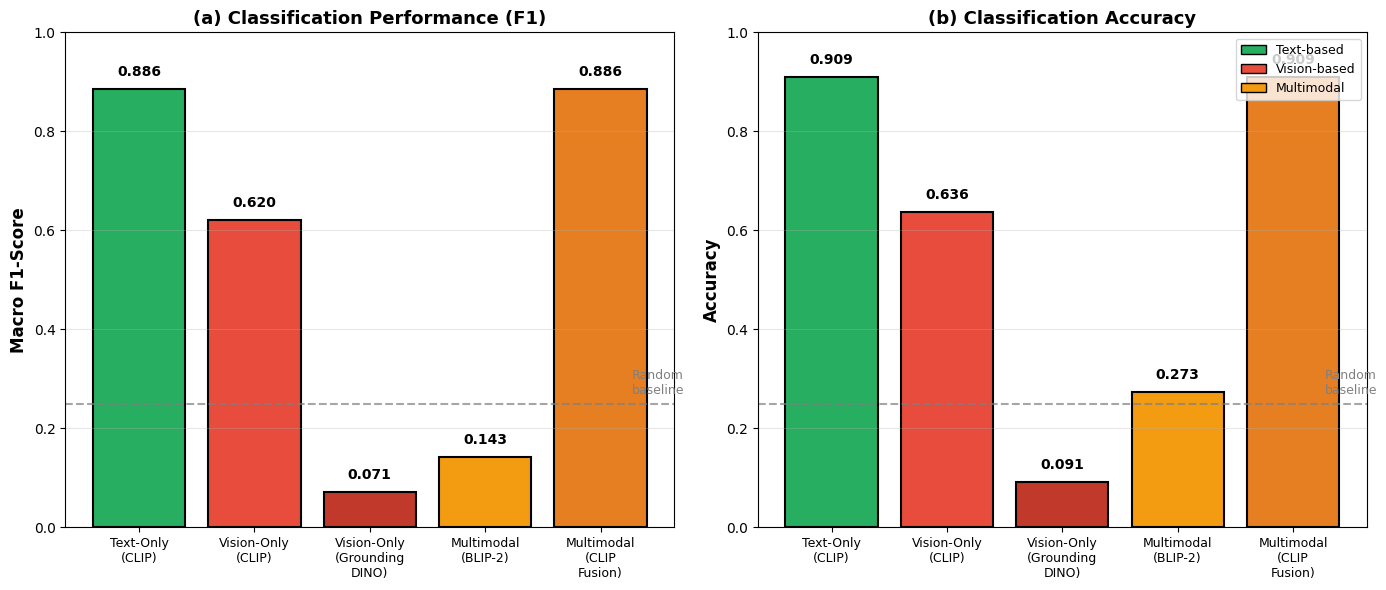


Figure saved: geomm_results/Figure2_Results_Comparison.png


In [19]:
# ==================================================
# CELL 18: Visualization - Results Comparison
# ==================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_results_comparison(df_metrics):
    """
    Create comparison plot of all approaches.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    approaches = df_metrics["approach"].tolist()
    x = np.arange(len(approaches))
    
    # Color coding by type
    colors = [
        "#27AE60",  # Text-only - green
        "#E74C3C",  # Vision CLIP - red
        "#C0392B",  # Vision Grounding - dark red
        "#F39C12",  # Multimodal BLIP-2 - orange
        "#E67E22",  # Multimodal Fusion - dark orange
    ]
    
    # Panel A: F1 Score
    ax1 = axes[0]
    f1_scores = df_metrics["f1_macro"].tolist()
    bars1 = ax1.bar(x, f1_scores, color=colors, edgecolor="black", linewidth=1.5)
    
    ax1.axhline(y=0.25, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
    ax1.text(len(approaches)-0.5, 0.27, "Random\nbaseline", fontsize=9, color="gray", ha="center")
    
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f"{height:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
    
    ax1.set_ylabel("Macro F1-Score", fontsize=12, fontweight="bold")
    ax1.set_title("(a) Classification Performance (F1)", fontsize=13, fontweight="bold")
    ax1.set_xticks(x)
    ax1.set_xticklabels([a.replace(" ", "\n") for a in approaches], fontsize=9)
    ax1.set_ylim([0, 1.0])
    ax1.grid(axis="y", alpha=0.3)
    
    # Panel B: Accuracy
    ax2 = axes[1]
    accuracies = df_metrics["accuracy"].tolist()
    bars2 = ax2.bar(x, accuracies, color=colors, edgecolor="black", linewidth=1.5)
    
    ax2.axhline(y=0.25, color="gray", linestyle="--", linewidth=1.5, alpha=0.7)
    ax2.text(len(approaches)-0.5, 0.27, "Random\nbaseline", fontsize=9, color="gray", ha="center")
    
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f"{height:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=10)
    
    ax2.set_ylabel("Accuracy", fontsize=12, fontweight="bold")
    ax2.set_title("(b) Classification Accuracy", fontsize=13, fontweight="bold")
    ax2.set_xticks(x)
    ax2.set_xticklabels([a.replace(" ", "\n") for a in approaches], fontsize=9)
    ax2.set_ylim([0, 1.0])
    ax2.grid(axis="y", alpha=0.3)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#27AE60", edgecolor="black", label="Text-based"),
        Patch(facecolor="#E74C3C", edgecolor="black", label="Vision-based"),
        Patch(facecolor="#F39C12", edgecolor="black", label="Multimodal"),
    ]
    ax2.legend(handles=legend_elements, loc="upper right", fontsize=9)
    
    plt.tight_layout()
    return fig

# Generate plot
fig = plot_results_comparison(df_metrics)
fig.savefig(f"{CONFIG['output_dir']}/Figure2_Results_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFigure saved: {CONFIG['output_dir']}/Figure2_Results_Comparison.png")

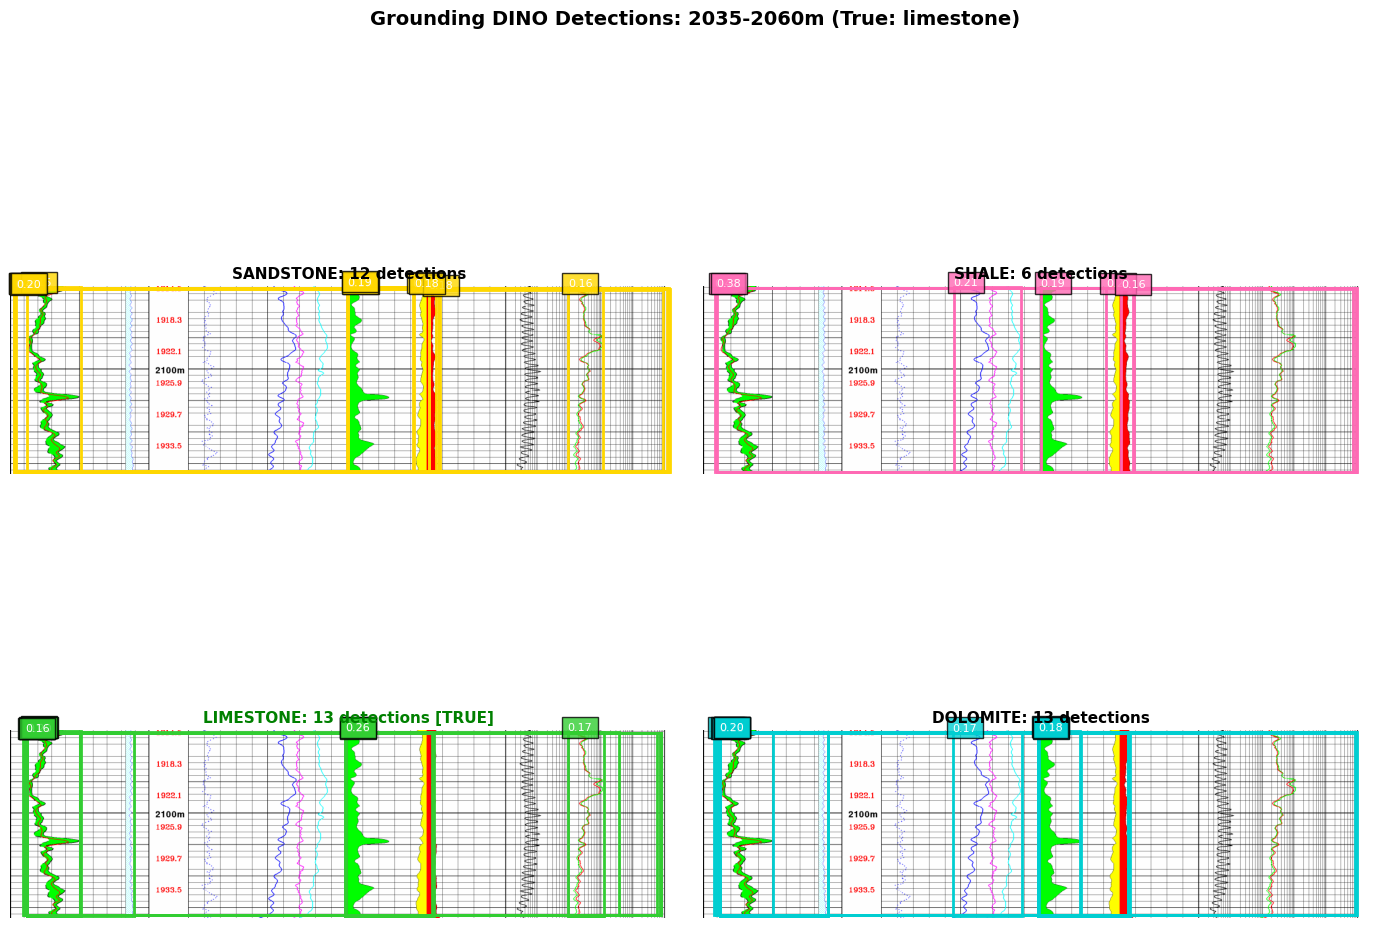

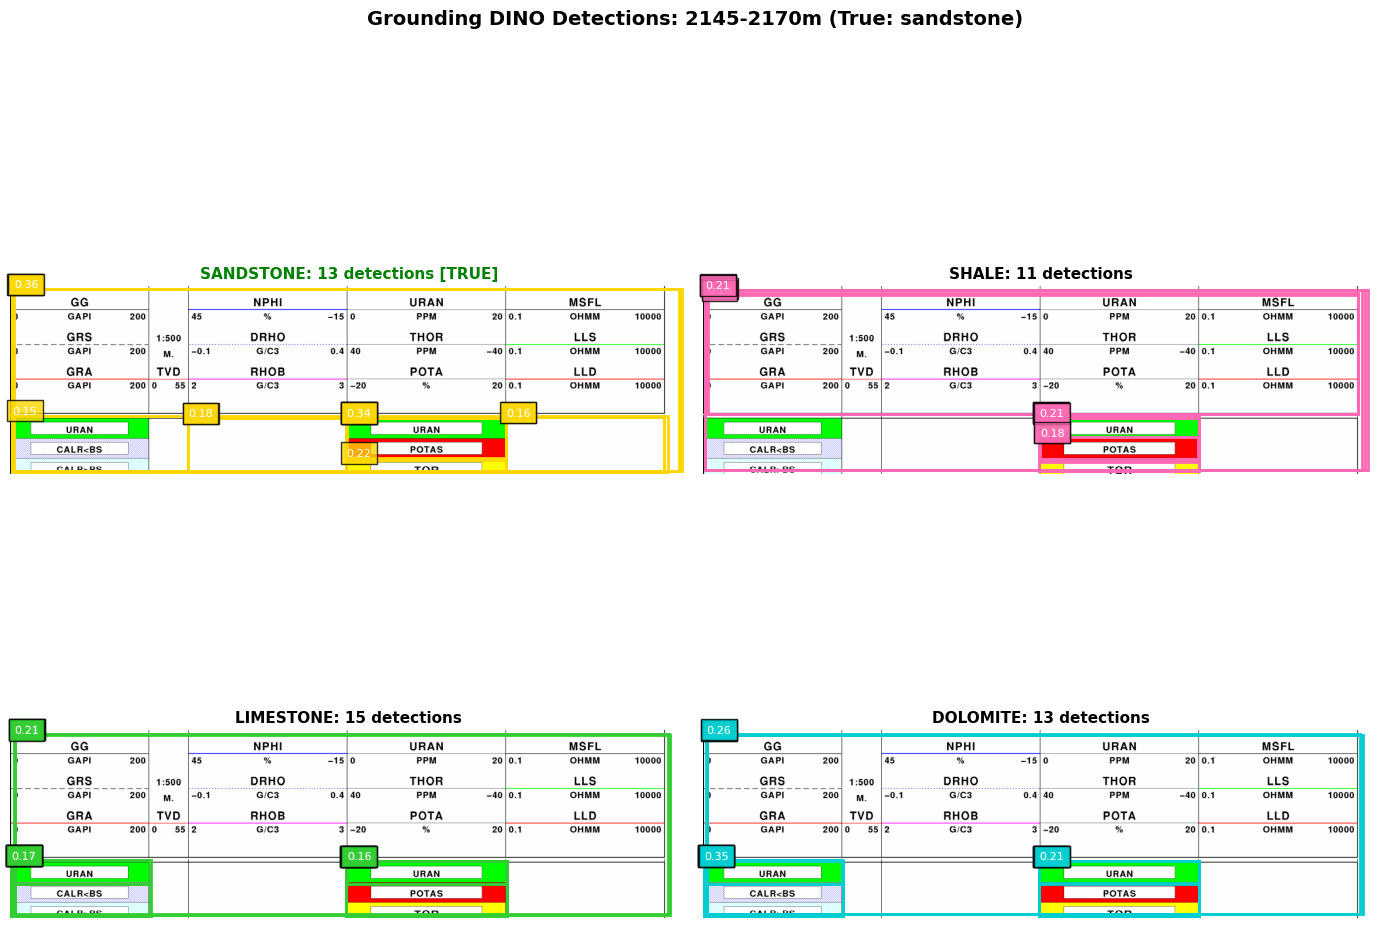

In [20]:
# ==================================================
# CELL 19: Visualization - Grounding Examples
# ==================================================

import matplotlib.patches as patches

def visualize_grounding_example(interval_idx=3):
    """
    Visualize grounding detections for a single interval.
    """
    gt = GROUND_TRUTH[interval_idx]
    page = gt["page"]
    start = gt["start_depth"]
    end = gt["end_depth"]
    true_label = gt["lithology"]
    
    # Load and crop image
    image_path = IMAGE_PATHS["logs"].get(page)
    if not image_path:
        print("Image not found.")
        return
    
    full_image = Image.open(image_path).convert("RGB")
    cropped_image = crop_to_depth_interval(full_image, page, start, end)
    
    # Run grounding for all lithologies
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    colors = {
        "sandstone": "#FFD700",
        "shale": "#FF69B4",
        "limestone": "#32CD32",
        "dolomite": "#00CED1",
    }
    
    for ax, (lith, query) in zip(axes, GROUNDING_QUERIES.items()):
        ax.imshow(cropped_image)
        
        results = detect_with_grounding_dino(cropped_image, query, box_threshold=0.15, text_threshold=0.15)
        
        for box, score, label in zip(results['boxes'], results['scores'], results['labels']):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2,
                edgecolor=colors[lith],
                facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1-3, f"{score:.2f}", fontsize=8, color="white",
                   bbox=dict(facecolor=colors[lith], alpha=0.8))
        
        n_det = len(results['boxes'])
        is_true = lith == true_label
        title_suffix = " [TRUE]" if is_true else ""
        ax.set_title(f"{lith.upper()}: {n_det} detections{title_suffix}", 
                    fontsize=11, fontweight="bold",
                    color="green" if is_true else "black")
        ax.axis("off")
    
    fig.suptitle(f"Grounding DINO Detections: {start}-{end}m (True: {true_label})", 
                fontsize=14, fontweight="bold")
    plt.tight_layout()
    
    fig.savefig(f"{CONFIG['output_dir']}/grounding_example_{start}_{end}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Visualize a limestone and sandstone example
visualize_grounding_example(interval_idx=3)  # Limestone
visualize_grounding_example(interval_idx=8)  # Sandstone

In [21]:
# ==================================================
# CELL 20: Detailed Results Table
# ==================================================

def create_results_table(df_results):
    """
    Create detailed results table showing all predictions.
    """
    # Select columns to display
    display_cols = [
        "interval_id",
        "start_depth",
        "end_depth",
        "true_label",
        "text_only_pred",
        "text_only_correct",
        "vision_clip_pred",
        "vision_clip_correct",
        "vision_grounding_pred",
        "vision_grounding_correct",
        "multimodal_blip2_pred",
        "multimodal_blip2_correct",
        "multimodal_fusion_pred",
        "multimodal_fusion_correct",
    ]
    
    df_display = df_results[display_cols].copy()
    
    # Rename columns for display
    df_display.columns = [
        "ID", "Start", "End", "True",
        "Text", "T_OK",
        "V_CLIP", "VC_OK",
        "V_Ground", "VG_OK",
        "M_BLIP", "MB_OK",
        "M_Fusion", "MF_OK",
    ]
    
    return df_display

print("\n" + "="*70)
print("DETAILED PREDICTIONS")
print("="*70)

df_display = create_results_table(df_results)
print(df_display.to_string(index=False))


DETAILED PREDICTIONS
 ID  Start  End      True      Text  T_OK    V_CLIP  VC_OK  V_Ground  VG_OK    M_BLIP  MB_OK  M_Fusion  MF_OK
  1   1975 1995     shale     shale  True limestone  False  dolomite  False sandstone  False     shale   True
  2   1995 2015     shale     shale  True limestone  False sandstone  False sandstone  False     shale   True
  3   2015 2035 limestone limestone  True limestone   True  dolomite  False sandstone  False limestone   True
  4   2035 2060 limestone limestone  True limestone   True sandstone  False sandstone  False limestone   True
  5   2060 2085 limestone limestone  True limestone   True  dolomite  False sandstone  False limestone   True
  6   2085 2110 limestone limestone  True     shale  False  dolomite  False sandstone  False limestone   True
  7   2110 2125 limestone limestone  True limestone   True  dolomite  False sandstone  False limestone   True
  8   2125 2145 sandstone sandstone  True     shale  False  dolomite  False sandstone   True sands

In [23]:
# ==================================================
# CELL 21: Summary and Analysis
# ==================================================

print("\n" + "="*70)
print("EXPERIMENT SUMMARY")
print("="*70)

# Find best and worst performers
best_idx = df_metrics["f1_macro"].idxmax()
worst_idx = df_metrics["f1_macro"].idxmin()

best_approach = df_metrics.loc[best_idx]
worst_approach = df_metrics.loc[worst_idx]

print(f"""
Dataset: {CONFIG['well_name']} ({CONFIG['country']})
Intervals: {len(GROUND_TRUTH)}
Depth range: {GROUND_TRUTH[0]['start_depth']}-{GROUND_TRUTH[-1]['end_depth']}m

BEST PERFORMER:
  {best_approach['approach']}
  - Accuracy: {best_approach['accuracy']:.3f}
  - F1 (macro): {best_approach['f1_macro']:.3f}

WORST PERFORMER:
  {worst_approach['approach']}
  - Accuracy: {worst_approach['accuracy']:.3f}
  - F1 (macro): {worst_approach['f1_macro']:.3f}

KEY FINDINGS:
""")

# Calculate domain gap
text_f1 = df_metrics[df_metrics["approach"].str.contains("Text")]["f1_macro"].values[0]
vision_clip_f1 = df_metrics[df_metrics["approach"] == "Vision-Only (CLIP)"]["f1_macro"].values[0]
vision_ground_f1 = df_metrics[df_metrics["approach"] == "Vision-Only (Grounding DINO)"]["f1_macro"].values[0]

domain_gap_clip = (text_f1 - vision_clip_f1) * 100
domain_gap_ground = (text_f1 - vision_ground_f1) * 100

print(f"  1. Text-only F1: {text_f1:.3f}")
print(f"  2. Vision CLIP F1: {vision_clip_f1:.3f} (domain gap: {domain_gap_clip:.1f} pp)")
print(f"  3. Vision Grounding F1: {vision_ground_f1:.3f} (domain gap: {domain_gap_ground:.1f} pp)")

if vision_ground_f1 > vision_clip_f1:
    improvement = (vision_ground_f1 - vision_clip_f1) * 100
    print(f"  4. Grounding DINO improves vision by {improvement:.1f} percentage points over CLIP")
else:
    print(f"  4. Grounding DINO does not improve over CLIP for this dataset")


EXPERIMENT SUMMARY

Dataset: Vilkyciai-22 (Lithuania)
Intervals: 11
Depth range: 1975-2215m

BEST PERFORMER:
  Text-Only (CLIP)
  - Accuracy: 0.909
  - F1 (macro): 0.886

WORST PERFORMER:
  Vision-Only (Grounding DINO)
  - Accuracy: 0.091
  - F1 (macro): 0.071

KEY FINDINGS:

  1. Text-only F1: 0.886
  2. Vision CLIP F1: 0.620 (domain gap: 26.6 pp)
  3. Vision Grounding F1: 0.071 (domain gap: 81.4 pp)
  4. Grounding DINO does not improve over CLIP for this dataset


In [26]:
# ==================================================
# CELL 22: Save All Results
# ==================================================

import json

# Helper function to convert numpy types for JSON serialization
def convert_to_native(obj):
    """Convert numpy types to native Python types for JSON serialization."""
    if isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native(v) for v in obj]
    elif hasattr(obj, 'item'):  # numpy scalar
        return obj.item()
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

# Save detailed results
df_results.to_csv(f"{CONFIG['output_dir']}/detailed_results.csv", index=False)

# Save metrics
df_metrics.to_csv(f"{CONFIG['output_dir']}/metrics_summary.csv", index=False)

# Save findings as JSON
findings = {
    "experiment": "GeoMM-Bench Comprehensive Evaluation",
    "well": CONFIG["well_name"],
    "n_intervals": len(GROUND_TRUTH),
    "depth_range": f"{GROUND_TRUTH[0]['start_depth']}-{GROUND_TRUTH[-1]['end_depth']}m",
    "metrics": convert_to_native(df_metrics.to_dict(orient="records")),
    "key_findings": {
        "best_approach": best_approach["approach"],
        "best_f1": float(best_approach["f1_macro"]),
        "domain_gap_clip": float(domain_gap_clip),
        "domain_gap_grounding": float(domain_gap_ground),
        "text_outperforms_vision": text_f1 > max(vision_clip_f1, vision_ground_f1),
    },
    "conclusion": "Text-based classification using CLIP's text encoder significantly outperforms "
                  "vision-based approaches on well log lithofacies classification. "
                  "This domain gap indicates that general-purpose vision encoders "
                  "require domain adaptation for geological image interpretation."
}

with open(f"{CONFIG['output_dir']}/experiment_findings.json", "w") as f:
    json.dump(convert_to_native(findings), f, indent=2)

print("\nResults saved:")
print(f"  - {CONFIG['output_dir']}/detailed_results.csv")
print(f"  - {CONFIG['output_dir']}/metrics_summary.csv")
print(f"  - {CONFIG['output_dir']}/experiment_findings.json")
print(f"  - {CONFIG['output_dir']}/Figure2_Results_Comparison.png")

print("\nExperiment complete.")


Results saved:
  - geomm_results/detailed_results.csv
  - geomm_results/metrics_summary.csv
  - geomm_results/experiment_findings.json
  - geomm_results/Figure2_Results_Comparison.png

Experiment complete.
